   Temp_Matriz_C  Presion_Inyeccion_Bar  Tiempo_Ciclo_s  Vibracion_RMS  \
0          202.5                  169.7           10.76           4.21   
1          237.0                  165.9           11.31           5.66   
2          223.9                  154.4           13.98           2.13   
3          215.9                  177.4           10.38           2.15   
4          189.4                  132.0           14.09           4.28   

   Defectos_Lote  
0          29.11  
1          63.94  
2          18.82  
3          14.49  
4          39.75  
       Temp_Matriz_C  Presion_Inyeccion_Bar  Tiempo_Ciclo_s  Vibracion_RMS  \
count    2500.000000            2500.000000     2500.000000    2500.000000   
mean      209.932600             149.686880       11.455488       3.946732   
std        17.452996              17.306093        2.014139       1.417672   
min       180.100000             120.000000        8.000000       1.500000   
25%       194.500000             134.800000        

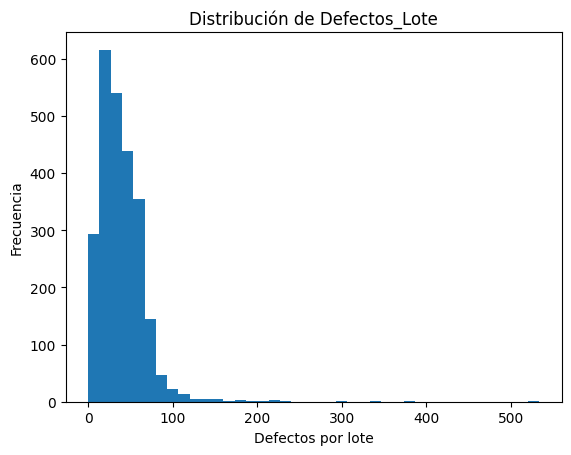

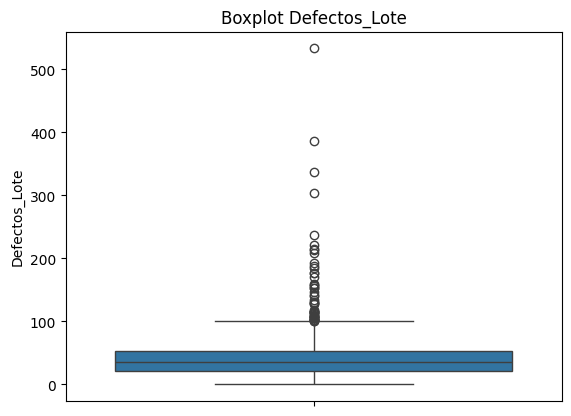

Asimetría: 4.653073083787883


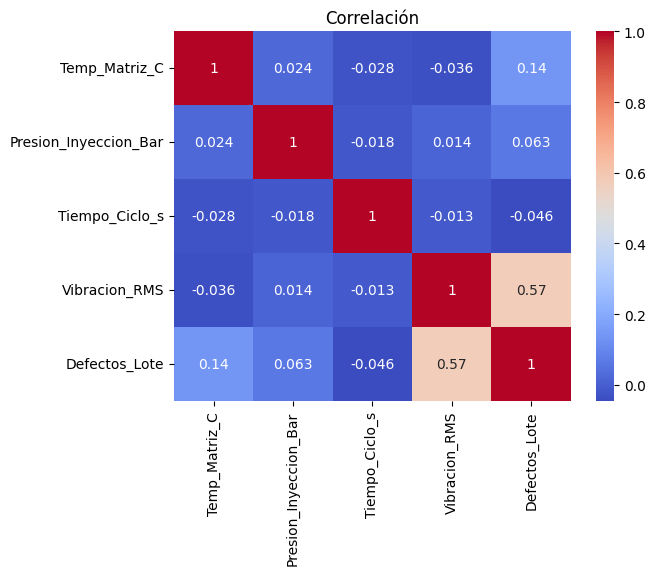

Mejores parámetros árbol: {'max_depth': 3, 'min_samples_split': 2}
MAE: 10.867411039650356
MSE: 300.7366545106504
R2: 0.4397927058644402
Mejores parámetros RF: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
MAE: 10.18494396477183
MSE: 260.0292432833165
R2: 0.5156218020284418
                variable  importancia
3          Vibracion_RMS     0.892773
0          Temp_Matriz_C     0.075342
1  Presion_Inyeccion_Bar     0.023883
2         Tiempo_Ciclo_s     0.008001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MAE: 9.812525405960084
MSE: 240.9998688301252
R2: 0.5510694078045348


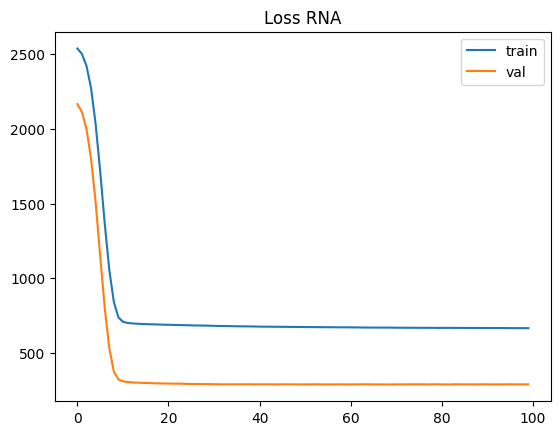

CV MSE Árbol: 638.4054751665151
CV MSE Random Forest: 625.5716887732935
              Modelo        MAE         MSE        R2
0  Árbol de Decisión  10.867411  300.736655  0.439793
1      Random Forest  10.184944  260.029243  0.515622
2                RNA   9.812525  240.999869  0.551069


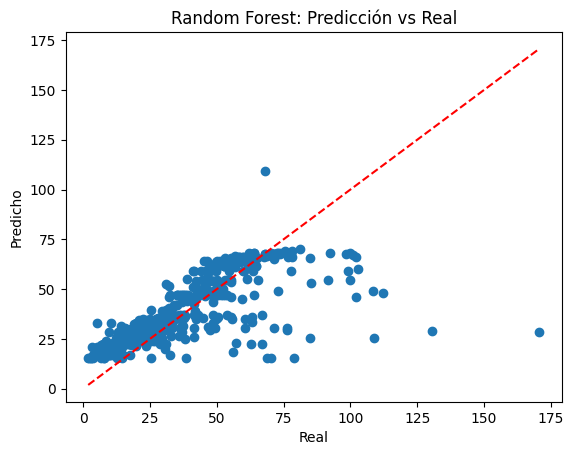

Predicción caso nuevo: [69.52664744]


In [ ]:

# CASO METALX - PREDICCIÓN DE DEFECTOS POR LOTE



# 1. IMPORTAR LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. CARGAR DATASET

datos = pd.read_csv("df_metalx.csv", sep=";")
print(datos.head())
print(datos.describe())


# 3. EDA


# nulos y duplicados
print(datos.isnull().sum())
print("Duplicados:", datos.duplicated().sum())

# histograma de la variable objetivo
plt.hist(datos["Defectos_Lote"], bins=40)
plt.title("Distribución de Defectos_Lote")
plt.xlabel("Defectos por lote")
plt.ylabel("Frecuencia")
plt.show()

# boxplot
sns.boxplot(y=datos["Defectos_Lote"])
plt.title("Boxplot Defectos_Lote")
plt.show()

print("Asimetría:", datos["Defectos_Lote"].skew())

# correlación
sns.heatmap(datos.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación")
plt.show()


# 4. VARIABLES

X = datos[["Temp_Matriz_C", "Presion_Inyeccion_Bar", "Tiempo_Ciclo_s", "Vibracion_RMS"]]
y = datos["Defectos_Lote"]


# 5. DIVISIÓN TRAIN/TEST

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# escalado para la red neuronal
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


# 6. ÁRBOL DE DECISIÓN + GRIDSEARCH

param_tree = {"max_depth": [3, 5], "min_samples_split": [2, 5, 10]}

grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_tree, cv=5)
grid_tree.fit(X_train, y_train)

modelo_tree = grid_tree.best_estimator_
pred_tree = modelo_tree.predict(X_test)

print("Mejores parámetros árbol:", grid_tree.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_tree))
print("MSE:", mean_squared_error(y_test, pred_tree))
print("R2:", r2_score(y_test, pred_tree))


# 7. RANDOM FOREST + GRIDSEARCH

param_rf = {"n_estimators": [100], "max_depth": [3, 5], "min_samples_split": [2, 5, 10]}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_rf, cv=5)
grid_rf.fit(X_train, y_train)

modelo_rf = grid_rf.best_estimator_
pred_rf = modelo_rf.predict(X_test)

print("Mejores parámetros RF:", grid_rf.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("MSE:", mean_squared_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))

# importancia de variables
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_rf.feature_importances_
}).sort_values("importancia", ascending=False)
print(importancias)


# 8. RED NEURONAL (RNA)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

modelo_rna = Sequential()
modelo_rna.add(Dense(16, activation="relu", input_shape=(X_train_sc.shape[1],)))
modelo_rna.add(Dense(8, activation="relu"))
modelo_rna.add(Dense(1, activation="linear"))

modelo_rna.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = modelo_rna.fit(X_train_sc, y_train, epochs=100, batch_size=32,
                          validation_split=0.2, verbose=0)

pred_rna = modelo_rna.predict(X_test_sc).flatten()

print("MAE:", mean_absolute_error(y_test, pred_rna))
print("MSE:", mean_squared_error(y_test, pred_rna))
print("R2:", r2_score(y_test, pred_rna))

# curva de entrenamiento
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss RNA")
plt.legend()
plt.show()


# 9. VALIDACIÓN CRUZADA (5 FOLDS)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_tree = cross_val_score(modelo_tree, X_train, y_train, cv=kf, scoring="neg_mean_squared_error")
cv_rf = cross_val_score(modelo_rf, X_train, y_train, cv=kf, scoring="neg_mean_squared_error")

print("CV MSE Árbol:", -cv_tree.mean())
print("CV MSE Random Forest:", -cv_rf.mean())


# 10. TABLA COMPARATIVA

resultados = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest", "RNA"],
    "MAE": [mean_absolute_error(y_test, pred_tree), mean_absolute_error(y_test, pred_rf), mean_absolute_error(y_test, pred_rna)],
    "MSE": [mean_squared_error(y_test, pred_tree), mean_squared_error(y_test, pred_rf), mean_squared_error(y_test, pred_rna)],
    "R2": [r2_score(y_test, pred_tree), r2_score(y_test, pred_rf), r2_score(y_test, pred_rna)]
})
print(resultados)


# 11. PREDICCIONES VS REALES

plt.scatter(y_test, pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Random Forest: Predicción vs Real")
plt.show()


# 12. PREDICCIÓN CON UN CASO NUEVO

nuevo = pd.DataFrame([{
    "Temp_Matriz_C": 238.0,
    "Presion_Inyeccion_Bar": 178.0,
    "Tiempo_Ciclo_s": 8.5,
    "Vibracion_RMS": 6.3
}])

print("Predicción caso nuevo:", modelo_rf.predict(nuevo))